In [3]:
import os
print(os.listdir())

['.config', 'Patna_Buisness_Dataset.xlsx', 'sample_data']


In [4]:
import pandas as pd

df = pd.read_excel("Patna_Buisness_Dataset.xlsx")
df.head()

,S.No,Business Name,Category,Address,Phone Number,Google Rating,Total Reviews,Price Level (1-4),Working Hours,Has Website?,Digital Growth Opportunity
0,1,Barkaas Patna,Restaurant,"Fourth Floor, Dumraon Place, Fraser Road Area,...",+91 75577 51884,4.6,3527,2,12:00 PM – 12:00 AM,No,High
1,2,Patna Darbar Restaurant,Restaurant,"R R Complex, Sadhan Path, Ashiana-Digha Rd, Ru...",+91 91428 05071,4.7,1692,2,11:00 AM – 11:00 PM,No,High
2,3,Vrihi Skydeck - Rooftop Restaurant,Restaurant,"Atal Path, near Rajdhani Apartment, Mahesh Nag...",+91 72950 54268,4.5,1574,3,10:00 AM – 11:00 PM,Yes,High
3,4,Amritsar Haveli Patna,Restaurant,"NC-6, Gayatri Mandir Rd, Kankarbagh, Patna, Bi...",+91 612 354 6985,4.7,1689,3,11:00 AM – 11:00 PM,No,High
4,5,Foresto Paradise,Restaurant,"8th floor, Patna One Plaza, New Dak Bunglow Rd...",+91 92644 55504,4.2,12320,3,10:30 AM – 11:30 PM,Yes,Medium


In [5]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   S.No                        49 non-null     int64  
 1   Business Name               49 non-null     object 
 2   Category                    49 non-null     object 
 3   Address                     49 non-null     object 
 4   Phone Number                49 non-null     object 
 5   Google Rating               49 non-null     float64
 6   Total Reviews               49 non-null     int64  
 7   Price Level (1-4)           49 non-null     int64  
 8   Working Hours               49 non-null     object 
 9   Has Website?                49 non-null     object 
 10  Digital Growth Opportunity  49 non-null     object 
dtypes: float64(1), int64(3), object(7)
memory usage: 4.3+ KB


,S.No,Business Name,Category,Address,Phone Number,Google Rating,Total Reviews,Price Level (1-4),Working Hours,Has Website?,Digital Growth Opportunity
count,49.00000,49,49,49,49,49.000000,49.000000,49.000000,49,49,49
unique,NaN,49,6,49,44,NaN,NaN,NaN,37,3,3
top,NaN,Barkaas Patna,Restaurant,"Fourth Floor, Dumraon Place, Fraser Road Area,...",Not listed,NaN,NaN,NaN,Open 24 hours,No,High
freq,NaN,1,10,1,6,NaN,NaN,NaN,6,33,34
mean,25.00000,NaN,NaN,NaN,NaN,4.640816,1390.734694,2.428571,NaN,NaN,NaN
std,14.28869,NaN,NaN,NaN,NaN,0.307489,2154.563904,0.612372,NaN,NaN,NaN
min,1.00000,NaN,NaN,NaN,NaN,3.400000,3.000000,1.000000,NaN,NaN,NaN
25%,13.00000,NaN,NaN,NaN,NaN,4.500000,253.000000,2.000000,NaN,NaN,NaN
50%,25.00000,NaN,NaN,NaN,NaN,4.700000,876.000000,2.000000,NaN,NaN,NaN
75%,37.00000,NaN,NaN,NaN,NaN,4.900000,1574.000000,3.000000,NaN,NaN,NaN


In [6]:
df.isnull().sum()

,0
S.No,0
Business Name,0
Category,0
Address,0
Phone Number,0
Google Rating,0
Total Reviews,0
Price Level (1-4),0
Working Hours,0
Has Website?,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
print(df.columns.tolist())

['S.No', 'Business Name', 'Category', 'Address', 'Phone Number', 'Google Rating', 'Total Reviews', 'Price Level (1-4)', 'Working Hours', 'Has Website?', 'Digital Growth Opportunity']


In [9]:
for col in df.select_dtypes(include="object"):
    df[col] = df[col].str.strip()

print("Data cleaned successfully!")

Data cleaned successfully!


In [10]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

encoders = {}

categorical_cols = [
    "Category",
    "Working Hours",
    "Has Website?",
    "Digital Growth Opportunity"
]

for col in categorical_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    encoders[col] = le

df_ml.head()

,S.No,Business Name,Category,Address,Phone Number,Google Rating,Total Reviews,Price Level (1-4),Working Hours,Has Website?,Digital Growth Opportunity
0,1,Barkaas Patna,4,"Fourth Floor, Dumraon Place, Fraser Road Area,...",+91 75577 51884,4.6,3527,2,17,0,0
1,2,Patna Darbar Restaurant,4,"R R Complex, Sadhan Path, Ashiana-Digha Rd, Ru...",+91 91428 05071,4.7,1692,2,11,0,0
2,3,Vrihi Skydeck - Rooftop Restaurant,4,"Atal Path, near Rajdhani Apartment, Mahesh Nag...",+91 72950 54268,4.5,1574,3,0,1,0
3,4,Amritsar Haveli Patna,4,"NC-6, Gayatri Mandir Rd, Kankarbagh, Patna, Bi...",+91 612 354 6985,4.7,1689,3,11,0,0
4,5,Foresto Paradise,4,"8th floor, Patna One Plaza, New Dak Bunglow Rd...",+91 92644 55504,4.2,12320,3,7,1,2


In [11]:
X = df_ml.drop(columns=[
    "S.No",
    "Business Name",
    "Address",
    "Phone Number",
    "Digital Growth Opportunity"
])

y = df_ml["Digital Growth Opportunity"]

print(X.head())

   Category  Google Rating  Total Reviews  Price Level (1-4)  Working Hours  \
0         4            4.6           3527                  2             17   
1         4            4.7           1692                  2             11   
2         4            4.5           1574                  3              0   
3         4            4.7           1689                  3             11   
4         4            4.2          12320                  3              7   

   Has Website?  
0             0  
1             0  
2             1  
3             0  
4             1  


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 39
Testing records: 10


In [13]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [14]:
y_pred = model.predict(X_test)

print(y_pred)

[0 2 1 2 0 0 0 0 0 0]


In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix
[[7 0 0]
 [0 1 0]
 [0 0 2]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         2

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [16]:
df_ml["Predicted Growth"] = model.predict(X)

df_ml.head()

,S.No,Business Name,Category,Address,Phone Number,Google Rating,Total Reviews,Price Level (1-4),Working Hours,Has Website?,Digital Growth Opportunity,Predicted Growth
0,1,Barkaas Patna,4,"Fourth Floor, Dumraon Place, Fraser Road Area,...",+91 75577 51884,4.6,3527,2,17,0,0,0
1,2,Patna Darbar Restaurant,4,"R R Complex, Sadhan Path, Ashiana-Digha Rd, Ru...",+91 91428 05071,4.7,1692,2,11,0,0,0
2,3,Vrihi Skydeck - Rooftop Restaurant,4,"Atal Path, near Rajdhani Apartment, Mahesh Nag...",+91 72950 54268,4.5,1574,3,0,1,0,0
3,4,Amritsar Haveli Patna,4,"NC-6, Gayatri Mandir Rd, Kankarbagh, Patna, Bi...",+91 612 354 6985,4.7,1689,3,11,0,0,0
4,5,Foresto Paradise,4,"8th floor, Patna One Plaza, New Dak Bunglow Rd...",+91 92644 55504,4.2,12320,3,7,1,2,2


             Feature  Importance
2      Total Reviews    0.366332
1      Google Rating    0.333709
4      Working Hours    0.200733
0           Category    0.068662
3  Price Level (1-4)    0.020618
5       Has Website?    0.009945


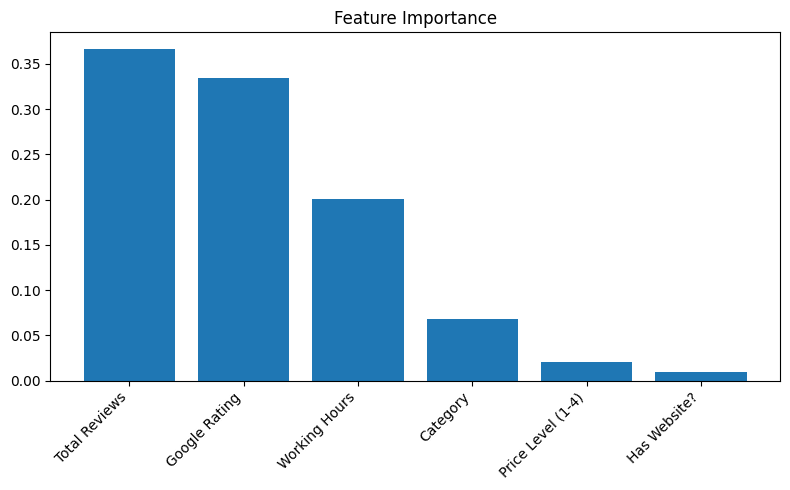

In [17]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))
plt.bar(importance["Feature"], importance["Importance"])
plt.xticks(rotation=45, ha="right")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

In [18]:
df_ml.to_csv("Business_Predictions.csv", index=False)

print("Business_Predictions.csv saved successfully!")

Business_Predictions.csv saved successfully!


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df = pd.read_excel("Patna_Buisness_Dataset.xlsx")
df.head()

,S.No,Business Name,Category,Address,Phone Number,Google Rating,Total Reviews,Price Level (1-4),Working Hours,Has Website?,Digital Growth Opportunity
0,1,Barkaas Patna,Restaurant,"Fourth Floor, Dumraon Place, Fraser Road Area,...",+91 75577 51884,4.6,3527,2,12:00 PM – 12:00 AM,No,High
1,2,Patna Darbar Restaurant,Restaurant,"R R Complex, Sadhan Path, Ashiana-Digha Rd, Ru...",+91 91428 05071,4.7,1692,2,11:00 AM – 11:00 PM,No,High
2,3,Vrihi Skydeck - Rooftop Restaurant,Restaurant,"Atal Path, near Rajdhani Apartment, Mahesh Nag...",+91 72950 54268,4.5,1574,3,10:00 AM – 11:00 PM,Yes,High
3,4,Amritsar Haveli Patna,Restaurant,"NC-6, Gayatri Mandir Rd, Kankarbagh, Patna, Bi...",+91 612 354 6985,4.7,1689,3,11:00 AM – 11:00 PM,No,High
4,5,Foresto Paradise,Restaurant,"8th floor, Patna One Plaza, New Dak Bunglow Rd...",+91 92644 55504,4.2,12320,3,10:30 AM – 11:30 PM,Yes,Medium


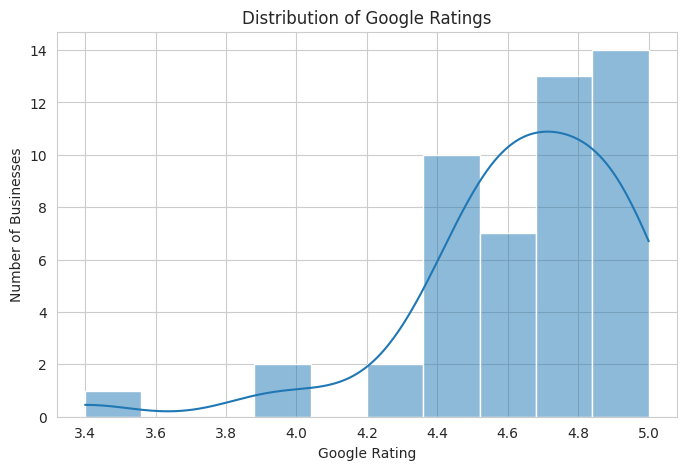

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(df["Google Rating"], bins=10, kde=True)

plt.title("Distribution of Google Ratings")
plt.xlabel("Google Rating")
plt.ylabel("Number of Businesses")

plt.show()

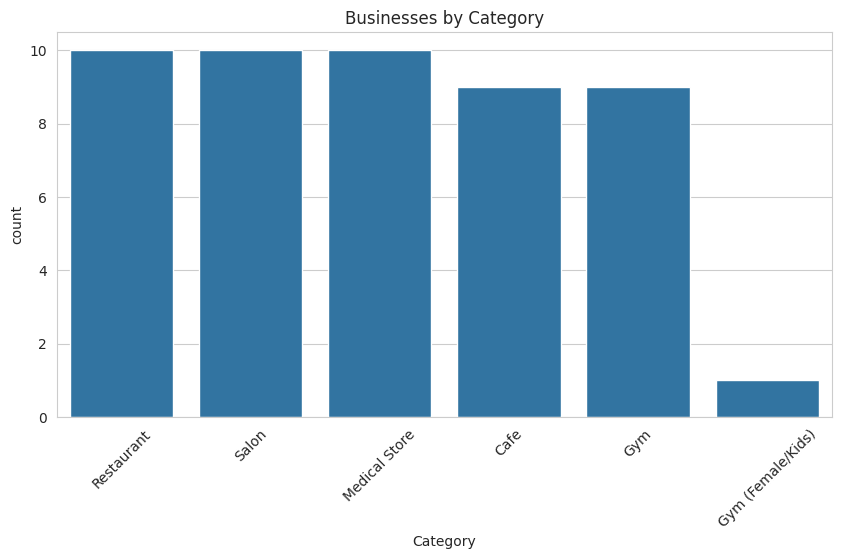

In [23]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Category",
    order=df["Category"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Businesses by Category")

plt.show()

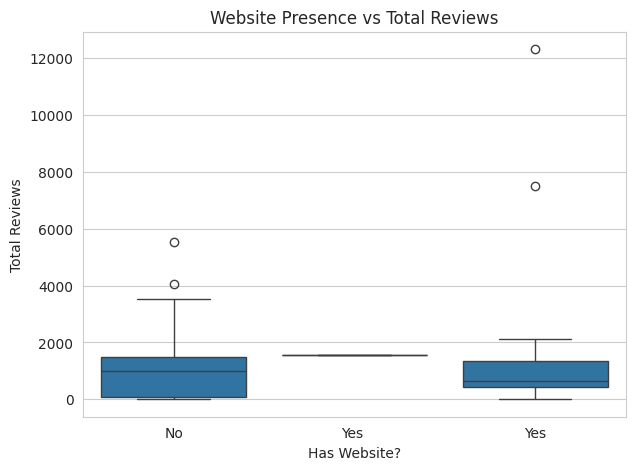

In [24]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Has Website?",
    y="Total Reviews"
)

plt.title("Website Presence vs Total Reviews")

plt.show()

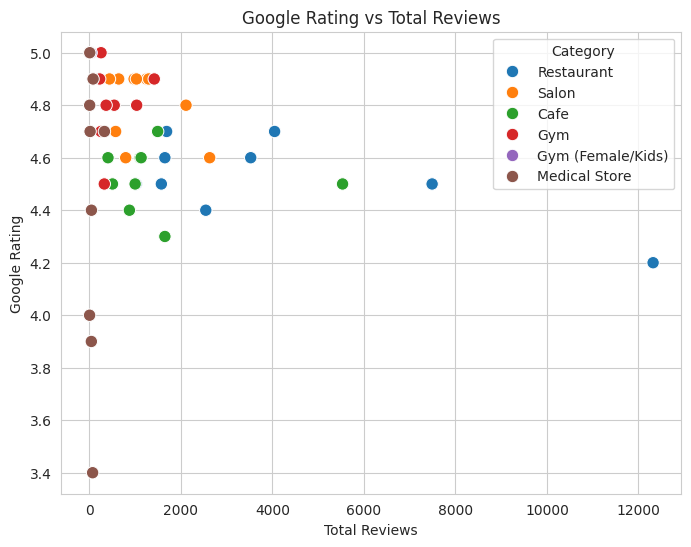

In [25]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Total Reviews",
    y="Google Rating",
    hue="Category",
    s=80
)

plt.title("Google Rating vs Total Reviews")

plt.show()

In [26]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

encoders = {}

categorical_cols = [
    "Category",
    "Working Hours",
    "Has Website?",
    "Digital Growth Opportunity"
]

for col in categorical_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    encoders[col] = le

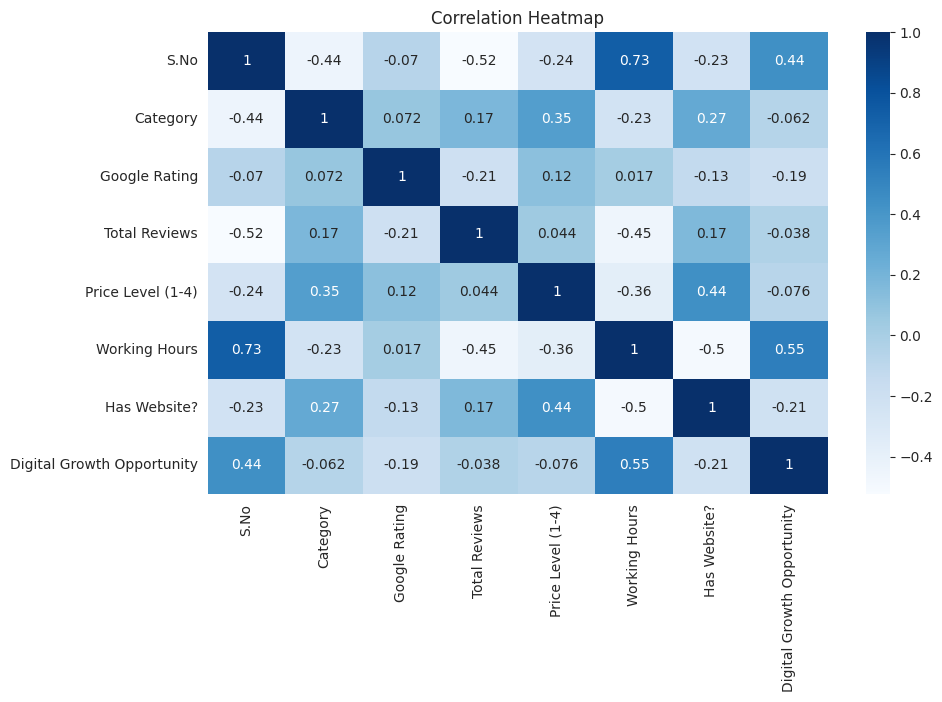

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    df_ml.corr(numeric_only=True),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")
plt.show()

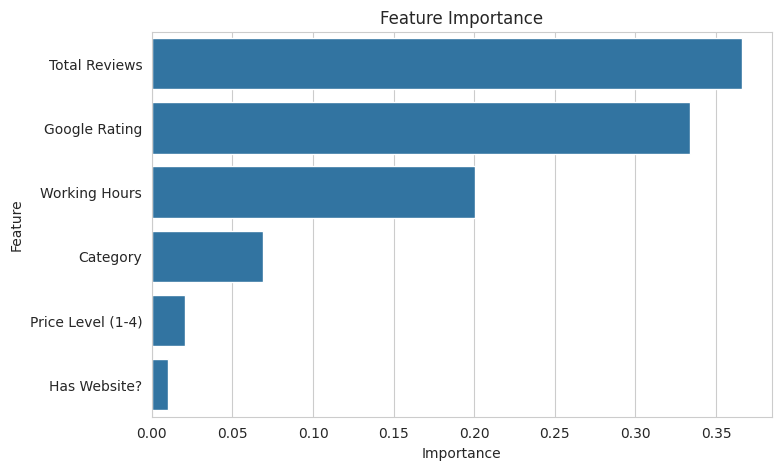

In [28]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [29]:
df_ml["Predicted Growth"] = model.predict(X)

In [30]:
df_ml.to_csv("Business_Predictions.csv", index=False)